In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

In [2]:
notebook = "syn1_Friedman_pt"
baseline_name = "syn1_Friedman_1_10000"

In [3]:
import numpy as np
import pandas as pd

# Friedman (1991): 10 predictors, only the first 5 are relevant
rng = np.random.default_rng(42)
n_samples = 2000
noise_std = 1.0

# X_j ~ Uniform(0, 1), j = 1, ..., 10
X_np = rng.uniform(0.0, 1.0, size=(n_samples, 10))
X = pd.DataFrame(X_np, columns=[f"x{i}" for i in range(1, 11)])

# y = 10 sin(pi x1 x2) + 20 (x3 - 0.5)^2 + 10 x4 + 5 x5 + eps
eps = rng.normal(0.0, noise_std, size=n_samples)
y = (
    10.0 * np.sin(np.pi * X["x1"] * X["x2"])
    + 20.0 * (X["x3"] - 0.5) ** 2
    + 10.0 * X["x4"]
    + 5.0 * X["x5"]
    + eps
)

In [4]:
X = X.values.astype(float)
y = np.array(y).reshape(-1)

In [5]:
ndpost = 10000
nskip = 500
n_trees = 100

In [6]:
from sklearn.model_selection import train_test_split
from bart_playground import ParallelTemperingBART
from sklearn.metrics import root_mean_squared_error
from experiment import count_leaves_in_trees, calculate_avg_depth_per_trace
import numpy as np
import time

# Keep the same split convention as experiment.py
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Keep default-BART structural settings aligned with experiment.py
proposal_probs_default = {
    "grow": 0.25,
    "prune": 0.25,
    "change": 0.4,
    "swap": 0.1,
}

# Match experiment store logic: keep only a fixed subset of test points in stored preds
n_test_points = 100

In [7]:
# Quick temperature ladder search on [1, 3], then build PT kwargs
def quick_ladder_search(
    X,
    y,
    proposal_probs,
    target_rate=0.4,
    max_rounds=10,
    ndpost=200,
    nskip=0,
    random_state=123,
):
    temps = [1.0, 3.0]

    for r in range(max_rounds):
        model = ParallelTemperingBART(
            ndpost=ndpost,
            nskip=nskip,
            n_trees=n_trees,
            tree_alpha=0.95,
            tree_beta=2.0,
            proposal_probs=proposal_probs,
            random_state=random_state + r,
            temperatures=temps,
            swap_interval=5,
            store_chain_traces=False,
            store_swap_diagnostics=False,
            print_swap_diagnostics=False,
        )
        model.fit(X, y, quietly=True)
        rates = model.get_params().get("swap_accept_rates", [])

        print(f"round {r}: temps={np.round(temps, 4).tolist()}")
        print(f"         rates={np.round(rates, 4).tolist()}")

        if len(rates) == 0 or all(rt >= target_rate for rt in rates):
            return temps, rates

        new_temps = set(temps)
        for i, rt in enumerate(rates):
            if rt < target_rate:
                new_temps.add(0.5 * (temps[i] + temps[i + 1]))
        temps = sorted(new_temps)

    # Final evaluation on the last ladder
    model = ParallelTemperingBART(
        ndpost=ndpost,
        nskip=nskip,
        n_trees=n_trees,
        tree_alpha=0.95,
        tree_beta=2.0,
        proposal_probs=proposal_probs,
        random_state=random_state + max_rounds,
        temperatures=temps,
        swap_interval=5,
        store_chain_traces=False,
        store_swap_diagnostics=False,
        print_swap_diagnostics=False,
    )
    model.fit(X, y, quietly=True)
    rates = model.get_params().get("swap_accept_rates", [])
    return temps, rates

# Use a subset for fast screening
search_temps, search_rates = quick_ladder_search(
    X_train[:500],
    y_train[:500],
    proposal_probs=proposal_probs_default,
    target_rate=0.4,
    max_rounds=10,
    ndpost=500,
    nskip=0,
 )

pt_kwargs = dict(
    ndpost=ndpost,
    nskip=nskip,
    n_trees=n_trees,
    tree_alpha=0.95,
    tree_beta=2.0,
    proposal_probs=proposal_probs_default,
    random_state=0,
    temperatures=search_temps,
    swap_interval=5,
    store_chain_traces=False,
)

print("\nSuggested temperatures:", [round(t, 4) for t in search_temps])
print("Final adjacent rates:", np.round(search_rates, 4).tolist())

round 0: temps=[1.0, 3.0]
         rates=[0.0]
round 1: temps=[1.0, 2.0, 3.0]
         rates=[0.01, 0.0]
round 2: temps=[1.0, 1.5, 2.0, 2.5, 3.0]
         rates=[0.015, 0.035, 0.085, 0.11]
round 3: temps=[1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
         rates=[0.0225, 0.16, 0.2175, 0.1975, 0.3725, 0.4, 0.52, 0.3425]
round 4: temps=[1.0, 1.125, 1.25, 1.375, 1.5, 1.625, 1.75, 1.875, 2.0, 2.125, 2.25, 2.5, 2.75, 2.875, 3.0]
         rates=[0.09, 0.3914, 0.3157, 0.4914, 0.4771, 0.5457, 0.6057, 0.53, 0.6629, 0.6643, 0.4371, 0.4886, 0.6986, 0.75]
round 5: temps=[1.0, 1.0625, 1.125, 1.1875, 1.25, 1.3125, 1.375, 1.5, 1.625, 1.75, 1.875, 2.0, 2.125, 2.25, 2.5, 2.75, 2.875, 3.0]
         rates=[0.4412, 0.4412, 0.5494, 0.6082, 0.6459, 0.6271, 0.4541, 0.4788, 0.5388, 0.5671, 0.6259, 0.6, 0.6341, 0.3553, 0.4871, 0.7, 0.7353]
round 6: temps=[1.0, 1.0625, 1.125, 1.1875, 1.25, 1.3125, 1.375, 1.5, 1.625, 1.75, 1.875, 2.0, 2.125, 2.25, 2.375, 2.5, 2.75, 2.875, 3.0]
         rates=[0.3689, 0.435

In [8]:
# PT-default-only run in notebook (no experiment.py changes)
pt_model = ParallelTemperingBART(**pt_kwargs)

_t0 = time.perf_counter()
pt_model.fit(X_train, y_train, quietly=False)
pt_fit_seconds = time.perf_counter() - _t0

# PT outputs on held-out test set (full), then subset for storage like experiment.py
pt_preds_2d_full = pt_model.posterior_f(X_test, backtransform=True)  # (n_test, ndpost)
pt_sigmas = np.array([s.global_params["eps_sigma2"][0] for s in pt_model.trace])
pt_rmses = np.array([root_mean_squared_error(y_test, pt_preds_2d_full[:, k]) for k in range(pt_preds_2d_full.shape[1])])
pt_leaves = np.array([count_leaves_in_trees(s) for s in pt_model.trace])
pt_depths = np.array([calculate_avg_depth_per_trace(s) for s in pt_model.trace])

# Coverage, consistent with experiment.py
pt_pred_all_test = pt_model.posterior_predict(X_test)
pt_lower = np.percentile(pt_pred_all_test, 2.5, axis=1)
pt_upper = np.percentile(pt_pred_all_test, 97.5, axis=1)
pt_covered_bool = ((y_test >= pt_lower) & (y_test <= pt_upper))

if n_test_points is not None and n_test_points < pt_preds_2d_full.shape[0]:
    rng = np.random.default_rng(42)
    idx_store = rng.choice(pt_preds_2d_full.shape[0], n_test_points, replace=False)
    pt_preds_2d = pt_preds_2d_full[idx_store]
    pt_coverage_store = pt_covered_bool[idx_store]
else:
    idx_store = np.arange(pt_preds_2d_full.shape[0])
    pt_preds_2d = pt_preds_2d_full
    pt_coverage_store = pt_covered_bool

# Save in experiment-like npz structure using notebook variable as filename
combined_results = {
    "default": {
        "sigmas": np.array([pt_sigmas]),
        "preds": np.array([pt_preds_2d]),
        "coverage": np.array([pt_coverage_store]),
        "rmses": np.array([pt_rmses]),
        "leaves": np.array([pt_leaves]),
        "depths": np.array([pt_depths]),
    },
    "metadata": {
        "n_runs": 1,
        "ndpost": ndpost,
        "nskip": nskip,
        "n_trees": n_trees,
        "model": "ParallelTemperingBART",
        "fit_seconds": pt_fit_seconds,
        "n_test_points": int(pt_preds_2d.shape[0]),
        "temperatures": pt_model.get_params().get("temperatures"),
        "swap_interval": pt_model.get_params().get("swap_interval"),
        "swap_accept_rates": pt_model.get_params().get("swap_accept_rates"),
    },
}
np.savez_compressed(f"store/{notebook}.npz", **combined_results)

print(f"PT fit done in {pt_fit_seconds:.2f}s")
print("PT temperatures:", pt_model.get_params().get("temperatures"))
print("PT swap accept rates:", pt_model.get_params().get("swap_accept_rates"))
print(f"Stored test points: {pt_preds_2d.shape[0]} / {X_test.shape[0]}")
print(f"Saved to store/{notebook}.npz")

Iterations: 100%|██████████| 10500/10500 [42:16<00:00,  4.14it/s]


PT fit done in 2536.19s
PT temperatures: [1.0, 1.03125, 1.0625, 1.125, 1.1875, 1.25, 1.3125, 1.375, 1.5, 1.625, 1.75, 1.875, 2.0, 2.125, 2.25, 2.375, 2.5, 2.75, 2.875, 3.0]
PT swap accept rates: [0.671328320802005, 0.6907268170426065, 0.45779448621553887, 0.5234085213032581, 0.5830576441102757, 0.586766917293233, 0.6177443609022556, 0.34922305764411027, 0.4275187969924812, 0.4708270676691729, 0.5281203007518797, 0.5180451127819549, 0.5662155388471178, 0.617593984962406, 0.6488721804511278, 0.6589473684210526, 0.41834586466165413, 0.6934837092731829, 0.7120802005012531]
Stored test points: 100 / 500
Saved to store/syn1_Friedman_pt.npz


In [9]:
import numpy as np

# Load both result files using the names defined above
baseline_npz = np.load(f"store/{baseline_name}.npz", allow_pickle=True)
notebook_npz = np.load(f"store/{notebook}.npz", allow_pickle=True)

baseline_store = baseline_npz["default"].item()
notebook_store = notebook_npz["default"].item()

# Stored arrays (typically n_runs x n_test_subset x ndpost)
preds_baseline_store = np.asarray(baseline_store["preds"])
sigmas_baseline_store = np.asarray(baseline_store["sigmas"])
rmses_baseline_store = np.asarray(baseline_store["rmses"])

preds_notebook_store = np.asarray(notebook_store["preds"])
sigmas_notebook_store = np.asarray(notebook_store["sigmas"])
rmses_notebook_store = np.asarray(notebook_store["rmses"])

# Normalize to (n_runs, n_test, ndpost) / (n_runs, ndpost)
if preds_baseline_store.ndim == 2:
    preds_baseline_store = preds_baseline_store[None, :, :]
if sigmas_baseline_store.ndim == 1:
    sigmas_baseline_store = sigmas_baseline_store[None, :]
if rmses_baseline_store.ndim == 1:
    rmses_baseline_store = rmses_baseline_store[None, :]

if preds_notebook_store.ndim == 2:
    preds_notebook_store = preds_notebook_store[None, :, :]
if sigmas_notebook_store.ndim == 1:
    sigmas_notebook_store = sigmas_notebook_store[None, :]
if rmses_notebook_store.ndim == 1:
    rmses_notebook_store = rmses_notebook_store[None, :]

# Reconstruct evaluation subset using the baseline stored shape
n_eval_points = preds_baseline_store.shape[1]
rng = np.random.default_rng(42)
if n_eval_points < X_test.shape[0]:
    idx_eval = rng.choice(X_test.shape[0], n_eval_points, replace=False)
else:
    idx_eval = np.arange(X_test.shape[0])

X_test_sub = X_test[idx_eval]
y_test_sub = y_test[idx_eval]
y_test_eval = y_test_sub

print("Baseline preds shape:", preds_baseline_store.shape)
print("Notebook preds shape:", preds_notebook_store.shape)
print("Evaluation y shape:", y_test_eval.shape)

Baseline preds shape: (1, 100, 10000)
Notebook preds shape: (1, 100, 10000)
Evaluation y shape: (100,)


In [10]:
# TabPFN baseline on the same evaluation subset
from sklearn.metrics import root_mean_squared_error

try:
    from tabpfn import TabPFNRegressor
except ImportError as e:
    raise ImportError(
        "tabpfn is not installed. Run in a cell: %pip install -U tabpfn"
    ) from e

tabpfn_model = TabPFNRegressor(random_state=42, ignore_pretraining_limits=True)
tabpfn_model.fit(X_train, y_train)
tabpfn_preds = tabpfn_model.predict(X_test_sub)
tabpfn_rmse = root_mean_squared_error(y_test_eval, tabpfn_preds)

print(f"RMSE (tabpfn, {notebook} subset): {tabpfn_rmse:.4f}")

RMSE (tabpfn, syn1_Friedman_pt subset): 1.0900


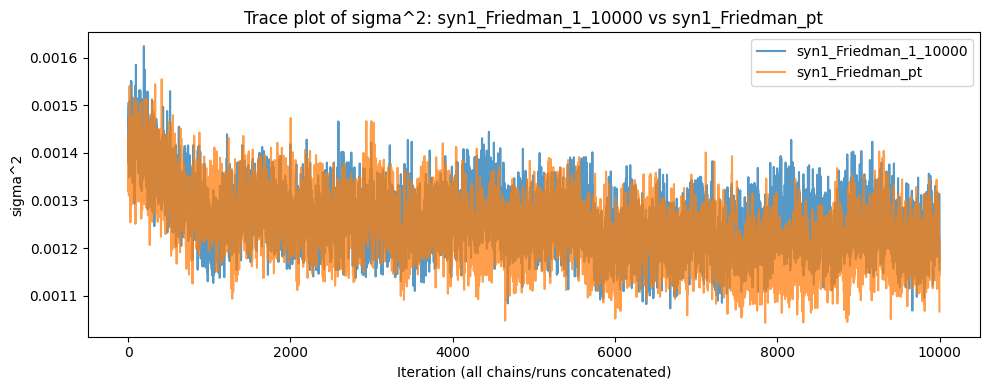

In [11]:
import matplotlib.pyplot as plt

# Sigma traces: concatenate runs/chains for visual comparison
sigma_baseline_trace = sigmas_baseline_store.reshape(-1)
sigma_notebook_trace = sigmas_notebook_store.reshape(-1)

plt.figure(figsize=(10, 4))
plt.plot(sigma_baseline_trace, label=baseline_name, alpha=0.75)
plt.plot(sigma_notebook_trace, label=notebook, alpha=0.75)
plt.xlabel("Iteration (all chains/runs concatenated)")
plt.ylabel("sigma^2")
plt.title(f"Trace plot of sigma^2: {baseline_name} vs {notebook}")
plt.legend()
plt.tight_layout()
plt.show()

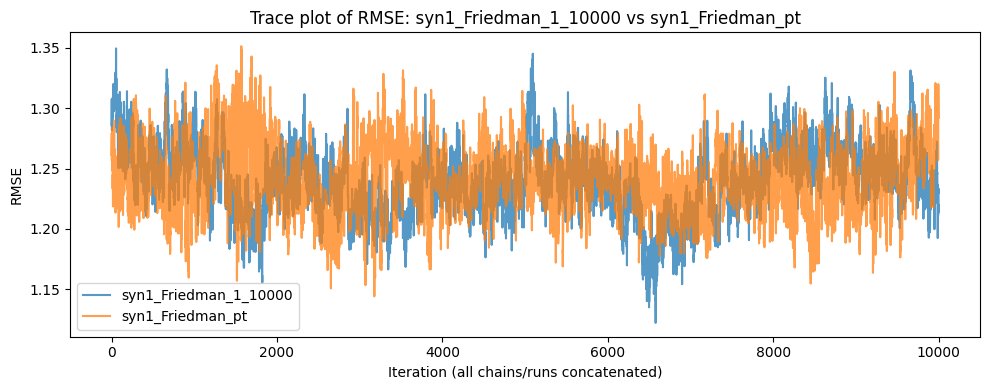

In [12]:
import matplotlib.pyplot as plt

# RMSE traces: concatenate runs/chains for visual comparison
rmse_baseline_trace = rmses_baseline_store.reshape(-1)
rmse_notebook_trace = rmses_notebook_store.reshape(-1)

plt.figure(figsize=(10, 4))
plt.plot(rmse_baseline_trace, label=baseline_name, alpha=0.75)
plt.plot(rmse_notebook_trace, label=notebook, alpha=0.75)
plt.xlabel("Iteration (all chains/runs concatenated)")
plt.ylabel("RMSE")
plt.title(f"Trace plot of RMSE: {baseline_name} vs {notebook}")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import root_mean_squared_error

# Posterior mean prediction RMSE on the matched test subset
mean_preds_baseline = preds_baseline_store.mean(axis=(0, 2))  # (n_test_subset,)
mean_preds_notebook = preds_notebook_store.mean(axis=(0, 2))  # (n_test_subset,)

rmse_baseline_mean = root_mean_squared_error(y_test_eval, mean_preds_baseline)
rmse_notebook_mean = root_mean_squared_error(y_test_eval, mean_preds_notebook)

print(f"RMSE (posterior mean, {baseline_name}): {rmse_baseline_mean:.4f}")
print(f"RMSE (posterior mean, {notebook}): {rmse_notebook_mean:.4f}")
if "tabpfn_rmse" in globals():
    print(f"RMSE (tabpfn): {tabpfn_rmse:.4f}")

RMSE (posterior mean, syn1_Friedman_1_10000): 1.1968
RMSE (posterior mean, syn1_Friedman_pt): 1.1342
RMSE (tabpfn): 1.0900


In [14]:
import numpy as np

def crps_from_samples(samples, y_true):
    """Compute CRPS per point from posterior samples.

    samples: (n_points, n_samples)
    y_true:  (n_points,)
    """
    n_points, n_samples = samples.shape
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)

    samples_sorted = np.sort(samples, axis=1)
    k = np.arange(1, n_samples + 1)
    coeffs = (2 * k - n_samples - 1)[None, :]
    term2 = np.sum(coeffs * samples_sorted, axis=1) / (n_samples ** 2)

    return term1 - term2

# Flatten runs/chains x ndpost into posterior sample dimension
n_runs_b, n_test_b, ndpost_b = preds_baseline_store.shape
samples_baseline = preds_baseline_store.transpose(1, 0, 2).reshape(n_test_b, n_runs_b * ndpost_b)

n_runs_n, n_test_n, ndpost_n = preds_notebook_store.shape
samples_notebook = preds_notebook_store.transpose(1, 0, 2).reshape(n_test_n, n_runs_n * ndpost_n)

crps_baseline = crps_from_samples(samples_baseline, y_test_eval)
crps_notebook = crps_from_samples(samples_notebook, y_test_eval)

print(f"Mean CRPS ({baseline_name}): {crps_baseline.mean():.6f}")
print(f"Mean CRPS ({notebook}): {crps_notebook.mean():.6f}")

Mean CRPS (syn1_Friedman_1_10000): 0.743417
Mean CRPS (syn1_Friedman_pt): 0.696893


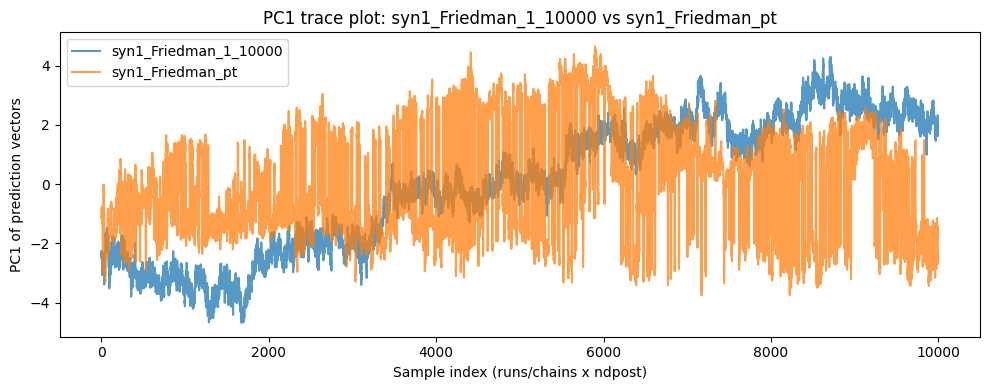

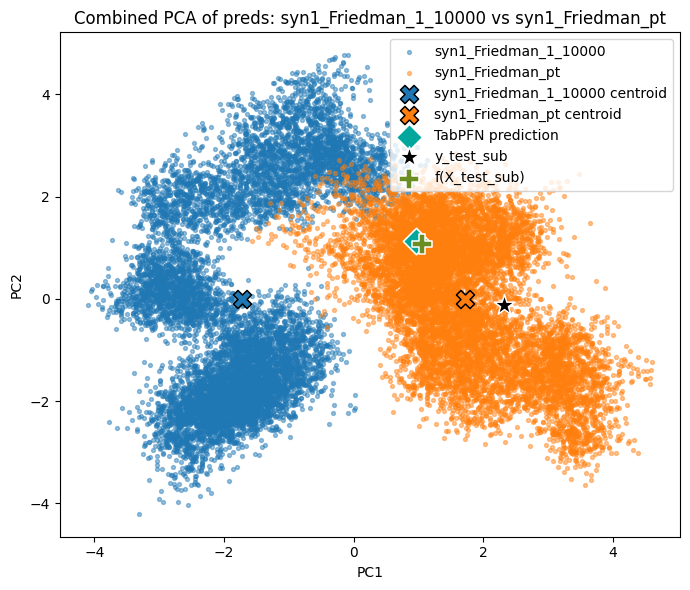

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Reshape: (n_runs, n_test, ndpost) -> (n_runs*ndpost, n_test)
def reshape_for_pca(preds):
    n_runs, n_test, ndpost = preds.shape
    return preds.transpose(0, 2, 1).reshape(-1, n_test)

X_baseline_pca = reshape_for_pca(preds_baseline_store)
X_notebook_pca = reshape_for_pca(preds_notebook_store)

# Separate PCA for each method -> PC1 trace
pc1_baseline = PCA(n_components=1).fit_transform(X_baseline_pca)[:, 0]
pc1_notebook = PCA(n_components=1).fit_transform(X_notebook_pca)[:, 0]

plt.figure(figsize=(10, 4))
plt.plot(pc1_baseline, label=baseline_name, alpha=0.75)
plt.plot(pc1_notebook, label=notebook, alpha=0.75)
plt.xlabel("Sample index (runs/chains x ndpost)")
plt.ylabel("PC1 of prediction vectors")
plt.title(f"PC1 trace plot: {baseline_name} vs {notebook}")
plt.legend()
plt.tight_layout()
plt.show()

# Combined PCA on stacked preds -> PC1 vs PC2
X_combined = np.vstack([X_baseline_pca, X_notebook_pca])
labels = np.array([baseline_name] * len(X_baseline_pca) + [notebook] * len(X_notebook_pca))

pca2 = PCA(n_components=2)
pc2 = pca2.fit_transform(X_combined)

plt.figure(figsize=(7, 6))
mask_b = labels == baseline_name
mask_n = labels == notebook
plt.scatter(pc2[mask_b, 0], pc2[mask_b, 1], s=8, alpha=0.45, label=baseline_name)
plt.scatter(pc2[mask_n, 0], pc2[mask_n, 1], s=8, alpha=0.45, label=notebook)

# Add centroids for the two compared methods
centroid_b = pc2[mask_b].mean(axis=0)
centroid_n = pc2[mask_n].mean(axis=0)
plt.scatter(
    centroid_b[0],
    centroid_b[1],
    s=170,
    c="#1f77b4",
    marker="X",
    edgecolors="black",
    linewidths=1.1,
    zorder=6,
    label=f"{baseline_name} centroid",
)
plt.scatter(
    centroid_n[0],
    centroid_n[1],
    s=170,
    c="#ff7f0e",
    marker="X",
    edgecolors="black",
    linewidths=1.1,
    zorder=6,
    label=f"{notebook} centroid",
)

if "tabpfn_preds" in globals():
    tabpfn_proj = pca2.transform(tabpfn_preds.reshape(1, -1))[0]
    y_proj = pca2.transform(y_test_sub.reshape(1, -1))[0]

    # Friedman noiseless signal: f(X_test_sub)
    f_test_sub = (
        10.0 * np.sin(np.pi * X_test_sub[:, 0] * X_test_sub[:, 1])
        + 20.0 * (X_test_sub[:, 2] - 0.5) ** 2
        + 10.0 * X_test_sub[:, 3]
        + 5.0 * X_test_sub[:, 4]
    )
    f_proj = pca2.transform(f_test_sub.reshape(1, -1))[0]

    plt.scatter(
        tabpfn_proj[0],
        tabpfn_proj[1],
        s=180,
        c="#00A79D",
        marker="D",
        edgecolors="white",
        linewidths=1.2,
        zorder=7,
        label="TabPFN prediction",
    )
    plt.scatter(
        y_proj[0],
        y_proj[1],
        s=240,
        c="black",
        marker="*",
        edgecolors="white",
        linewidths=1.1,
        zorder=7,
        label="y_test_sub",
    )
    plt.scatter(
        f_proj[0],
        f_proj[1],
        s=220,
        c="#6B8E23",
        marker="P",
        edgecolors="white",
        linewidths=1.1,
        zorder=7,
        label="f(X_test_sub)",
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Combined PCA of preds: {baseline_name} vs {notebook}")
plt.legend()
plt.tight_layout()
plt.show()

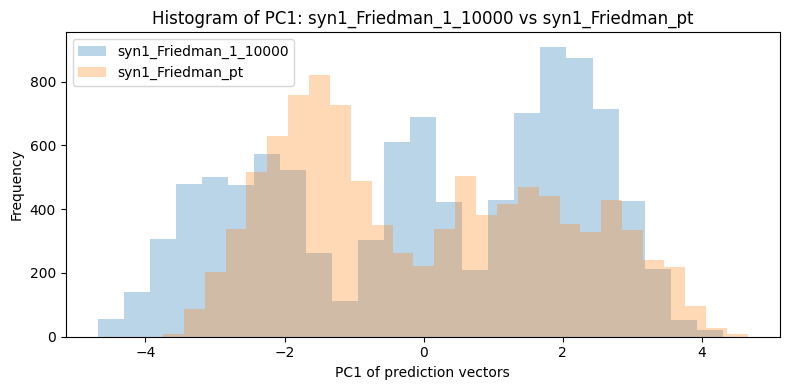

In [16]:
# Histogram of PC1
plt.figure(figsize=(8, 4))
plt.hist(pc1_baseline, bins="auto", alpha=0.3, label=baseline_name)
plt.hist(pc1_notebook, bins="auto", alpha=0.3, label=notebook)
plt.xlabel("PC1 of prediction vectors")
plt.ylabel("Frequency")
plt.title(f"Histogram of PC1: {baseline_name} vs {notebook}")
plt.legend()
plt.tight_layout()
plt.show()

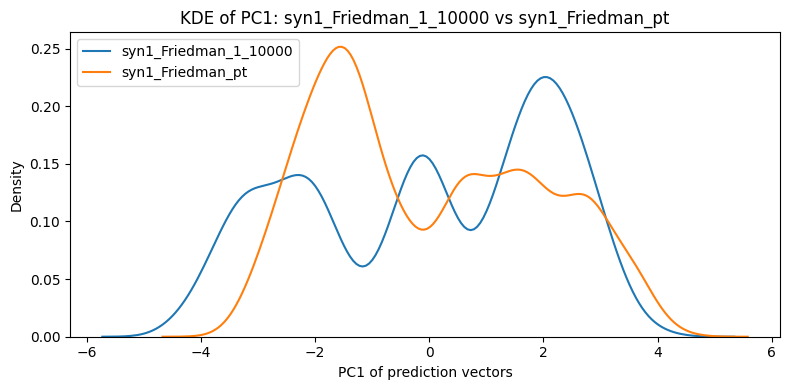

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(pc1_baseline, label=baseline_name, ax=ax, color="tab:blue")
sns.kdeplot(pc1_notebook, label=notebook, ax=ax, color="tab:orange")
ax.set_xlabel("PC1 of prediction vectors")
ax.set_ylabel("Density")
ax.set_title(f"KDE of PC1: {baseline_name} vs {notebook}")
ax.legend()
plt.tight_layout()
plt.show()

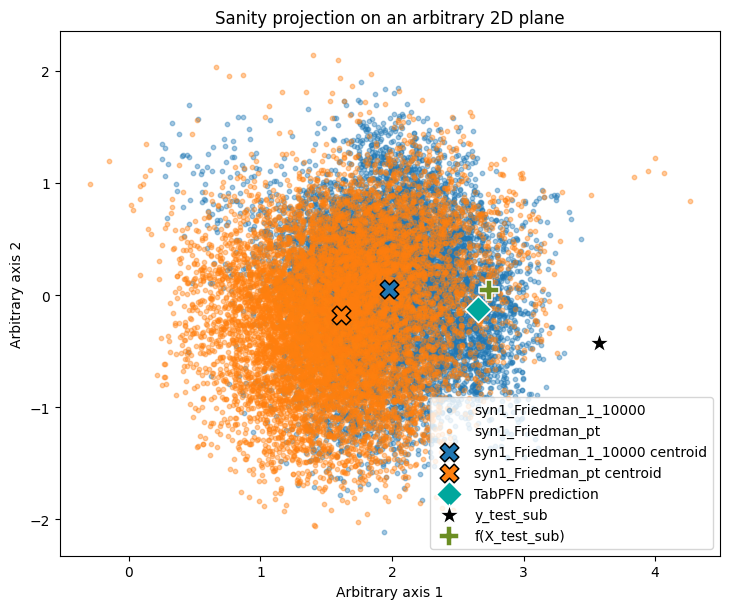

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Sanity test: project prediction vectors to an arbitrary 2D plane (not PCA)
required = ["preds_baseline_store", "preds_notebook_store", "X_test_sub", "y_test_sub"]
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f"Run prerequisite cells first. Missing: {missing}")

def reshape_for_plane(preds):
    # (n_runs, n_test, ndpost) -> (n_runs*ndpost, n_test)
    n_runs, n_test, ndpost = preds.shape
    return preds.transpose(0, 2, 1).reshape(-1, n_test)

Xb = reshape_for_plane(preds_baseline_store)
Xn = reshape_for_plane(preds_notebook_store)

if Xb.shape[1] != X_test_sub.shape[0] or Xn.shape[1] != X_test_sub.shape[0]:
    raise ValueError(
        "Dimension mismatch: prediction-vector length must equal len(X_test_sub)."
    )

# Build a deterministic random orthonormal basis in R^(n_test) for a 2D plane
rng_plane = np.random.default_rng(20260409)
A = rng_plane.normal(size=(X_test_sub.shape[0], 2))
Q, _ = np.linalg.qr(A)
W2 = Q[:, :2]  # columns form an orthonormal 2D basis

proj_b = Xb @ W2
proj_n = Xn @ W2

cent_b = proj_b.mean(axis=0)
cent_n = proj_n.mean(axis=0)

# Reference vectors on the same test subset
y_vec = y_test_sub.reshape(-1)
f_vec = (
    10.0 * np.sin(np.pi * X_test_sub[:, 0] * X_test_sub[:, 1])
    + 20.0 * (X_test_sub[:, 2] - 0.5) ** 2
    + 10.0 * X_test_sub[:, 3]
    + 5.0 * X_test_sub[:, 4]
)

y_proj = y_vec @ W2
f_proj = f_vec @ W2

tabpfn_proj = None
if "tabpfn_preds" in globals():
    tab_vec = np.asarray(tabpfn_preds).reshape(-1)
    if tab_vec.shape[0] == X_test_sub.shape[0]:
        tabpfn_proj = tab_vec @ W2

plt.figure(figsize=(7.4, 6.2))
plt.scatter(proj_b[:, 0], proj_b[:, 1], s=10, alpha=0.4, label=baseline_name)
plt.scatter(proj_n[:, 0], proj_n[:, 1], s=10, alpha=0.4, label=notebook)

plt.scatter(
    cent_b[0],
    cent_b[1],
    s=180,
    c="#1f77b4",
    marker="X",
    edgecolors="black",
    linewidths=1.1,
    zorder=6,
    label=f"{baseline_name} centroid",
)
plt.scatter(
    cent_n[0],
    cent_n[1],
    s=180,
    c="#ff7f0e",
    marker="X",
    edgecolors="black",
    linewidths=1.1,
    zorder=6,
    label=f"{notebook} centroid",
)

if tabpfn_proj is not None:
    plt.scatter(
        tabpfn_proj[0],
        tabpfn_proj[1],
        s=180,
        c="#00A79D",
        marker="D",
        edgecolors="white",
        linewidths=1.2,
        zorder=7,
        label="TabPFN prediction",
    )

plt.scatter(
    y_proj[0],
    y_proj[1],
    s=250,
    c="black",
    marker="*",
    edgecolors="white",
    linewidths=1.1,
    zorder=7,
    label="y_test_sub",
)
plt.scatter(
    f_proj[0],
    f_proj[1],
    s=220,
    c="#6B8E23",
    marker="P",
    edgecolors="white",
    linewidths=1.1,
    zorder=7,
    label="f(X_test_sub)",
)

plt.xlabel("Arbitrary axis 1")
plt.ylabel("Arbitrary axis 2")
plt.title("Sanity projection on an arbitrary 2D plane")
plt.legend()
plt.tight_layout()
plt.show()